<a href="https://colab.research.google.com/github/uddipta-deka/HeartDisease_Detection/blob/main/HeartStroke_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('/content/drive/MyDrive/HeartStroke_Prediction/heart.csv')

In [8]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


EDA

In [9]:
df.shape

(918, 12)

In [10]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [12]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [13]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

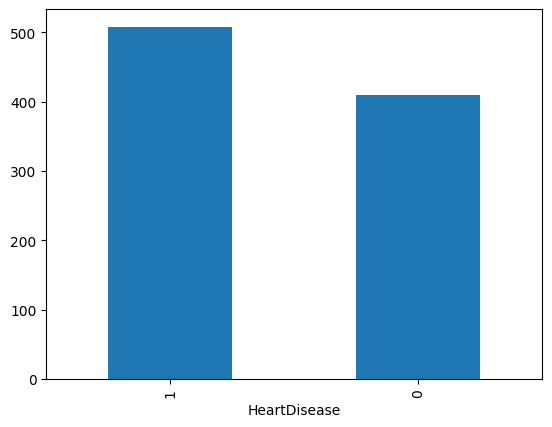

In [14]:
df['HeartDisease'].value_counts().plot(kind='bar')

In [15]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


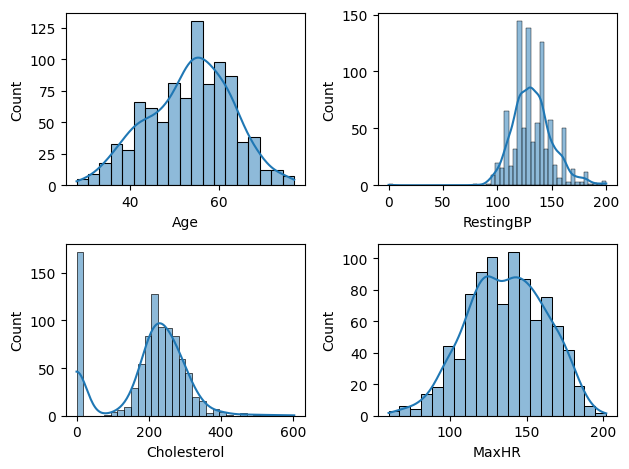

In [16]:
def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var],kde=True)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()



In [17]:
df['Cholesterol'].value_counts()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


In [18]:
ch_mean = df.loc[df['Cholesterol'] != 0,'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [19]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

In [20]:
resBP_mean = df.loc[df['RestingBP'] != 0,'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0,resBP_mean)
df['RestingB'] = df['RestingBP'].round(2)

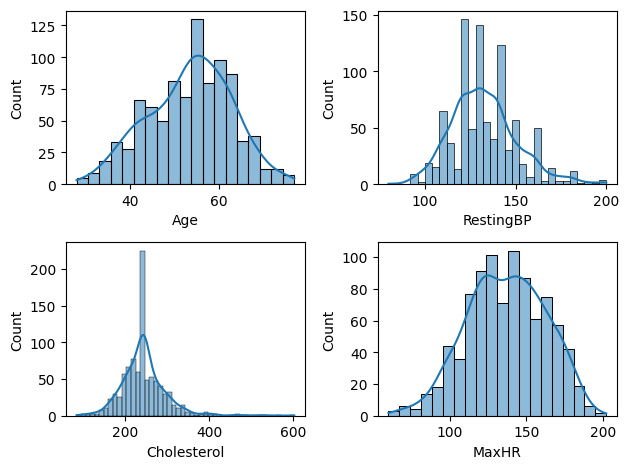

In [21]:
def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var],kde=True)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

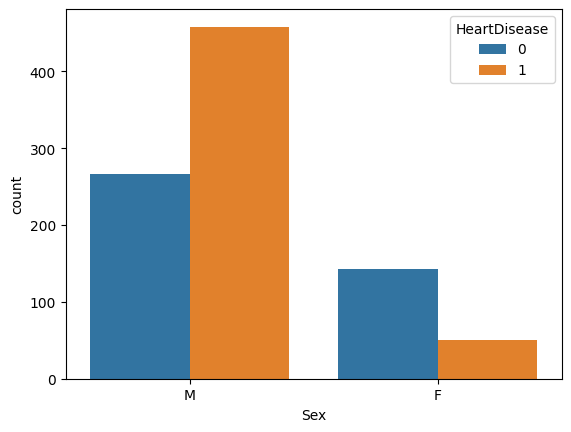

In [22]:
sns.countplot(x = df['Sex'],hue = df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

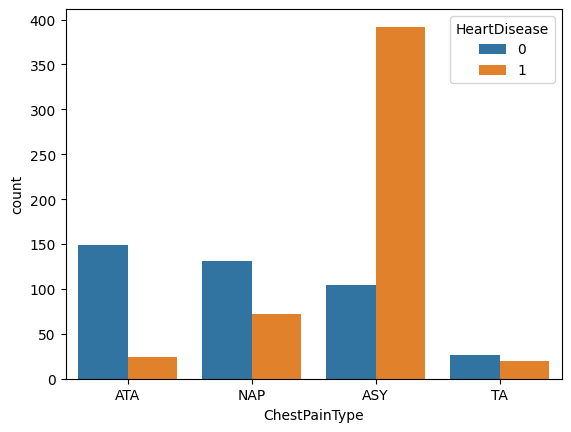

In [23]:
sns.countplot(x = df['ChestPainType'],hue= df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

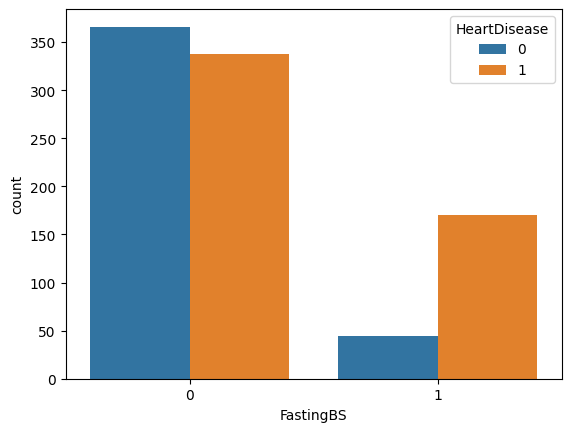

In [24]:
sns.countplot(x = df['FastingBS'],hue= df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

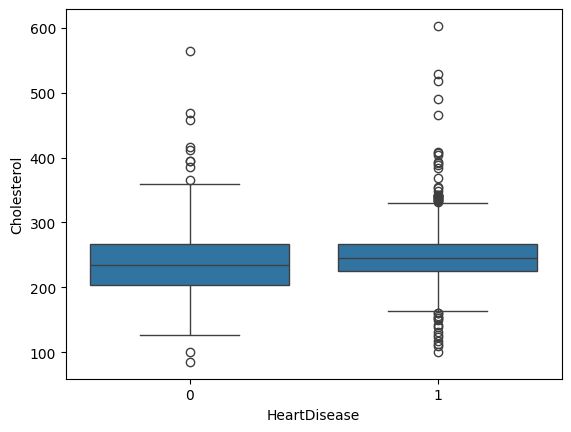

In [25]:
sns.boxplot(x = df['HeartDisease'],y = df['Cholesterol'])

<Axes: xlabel='HeartDisease', ylabel='Age'>

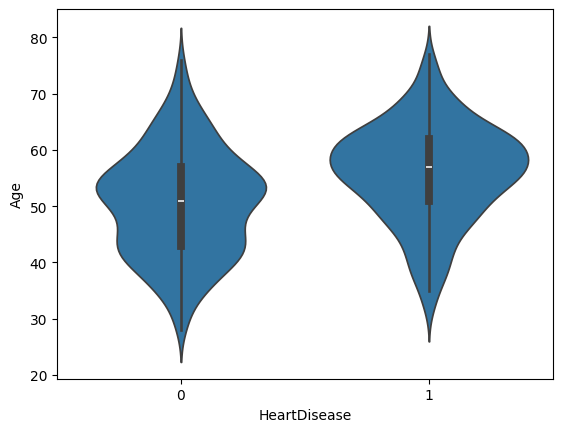

In [26]:
sns.violinplot(x = df['HeartDisease'], y =df['Age'])

<Axes: >

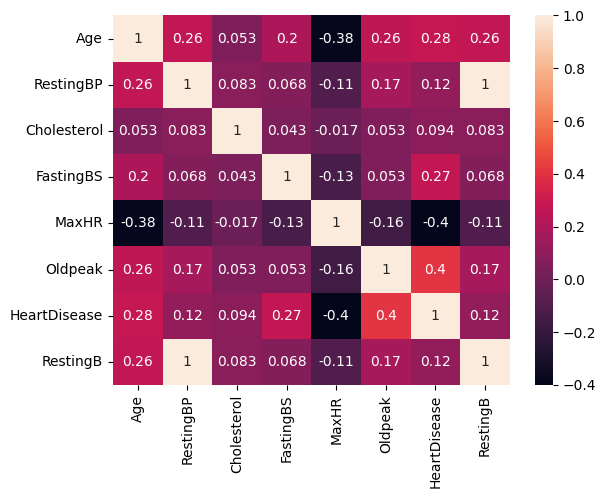

In [27]:
sns.heatmap(df.corr(numeric_only = True), annot=True)

DATA PREPROCESSING AND CLEANING

In [28]:
df_encode = pd.get_dummies(df,drop_first=True)
df_encode = df_encode.astype(int)

In [29]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,RestingB,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,140,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,160,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,130,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,138,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,150,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,110,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,144,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,130,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,130,0,1,0,0,0,0,0,1,0


In [30]:
from sklearn.preprocessing import StandardScaler
numercal_cols=['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scaler = StandardScaler()
df_encode[numercal_cols] = scaler.fit_transform(df_encode[numercal_cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,RestingB,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,140,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,160,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,130,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,138,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,150,1,0,1,0,1,0,0,0,1


In [31]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'RestingB', 'Sex_M', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal',
       'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [33]:
X = df_encode.drop('HeartDisease',axis=1)
Y = df_encode['HeartDisease']

In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [35]:
scaler = StandardScaler()
X_train_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.fit_transform(X_test)


In [36]:
models = {
    "logistic regression" : LogisticRegression(),
    "KNN" : KNeighborsClassifier(),
    "NaiveBayes" : GaussianNB(),
    "DescisionTree" : DecisionTreeClassifier(),
    "SVM" : SVC()
}


In [37]:
result = []

In [38]:
for name,model in models.items():
  model.fit(X_train_Scaled,Y_train)
  y_pred = model.predict(X_test_Scaled)
  accuracy = accuracy_score(Y_test,y_pred)
  f1 = f1_score(Y_test, y_pred)

  result.append({
      'model' : name,
      'accuracy' : round(accuracy,4),
      'f1_score' : round(f1,4)
  })

In [39]:
result

[{'model': 'logistic regression', 'accuracy': 0.8696, 'f1_score': 0.8857},
 {'model': 'KNN', 'accuracy': 0.8533, 'f1_score': 0.872},
 {'model': 'NaiveBayes', 'accuracy': 0.8533, 'f1_score': 0.8683},
 {'model': 'DescisionTree', 'accuracy': 0.7772, 'f1_score': 0.8},
 {'model': 'SVM', 'accuracy': 0.8478, 'f1_score': 0.8667}]

In [40]:
import joblib
joblib.dump(models['logistic regression'],'LogiReg_Heart.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']